# DGCNN

## Data

In [1]:
%pip install h5py 
%pip install plotly nbformat tqdm matplotlib
%pip install pykeops==2.1.2
%pip install faiss-gpu

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement faiss-gpu (from versions: none)
ERROR: No matching distribution found for faiss-gpu


In [ ]:
import pykeops
pykeops.test_torch_bindings()

In [3]:
%pip install pip install faiss-gpu

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install


In [4]:
import os
import glob
import h5py
import numpy as np
import urllib.request
import zipfile
from torch.utils.data import Dataset

def download():
    BASE_DIR = os.path.abspath('') 
    DATA_DIR = os.path.join(BASE_DIR, 'data')
    
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
        
    zip_path = os.path.join(DATA_DIR, 'modelnet40_ply_hdf5_2048.zip')
    extract_path = os.path.join(DATA_DIR, 'modelnet40_ply_hdf5_2048')
    
    if not os.path.exists(extract_path):
        url = 'https://shapenet.cs.stanford.edu/media/modelnet40_ply_hdf5_2048.zip'
        print(f"Download the dataset {url}... ")
        
        urllib.request.urlretrieve(url, zip_path)
        
        print("Extract zip file...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)
            
        print("Remove zip file...")
        os.remove(zip_path)
        print("Download dataset and ready to go")
    else:
        print("Dataset already exist in 'data/'.")

def load_data(partition):
    download()
    BASE_DIR = os.path.abspath('')
    DATA_DIR = os.path.join(BASE_DIR, 'data')
    all_data = []
    all_label = []
    
    for h5_name in glob.glob(os.path.join(DATA_DIR, 'modelnet40_ply_hdf5_2048', f'ply_data_{partition}*.h5')):
        with h5py.File(h5_name, 'r') as f:
            data = f['data'][:].astype('float32')
            label = f['label'][:].astype('int64')
            all_data.append(data)
            all_label.append(label)
            
    all_data = np.concatenate(all_data, axis=0)
    all_label = np.concatenate(all_label, axis=0)
    return all_data, all_label

def translate_pointcloud(pointcloud):
    """ Translation to augment the Data """
    xyz1 = np.random.uniform(low=2./3., high=3./2., size=[3])
    xyz2 = np.random.uniform(low=-0.2, high=0.2, size=[3])
    translated_pointcloud = np.add(np.multiply(pointcloud, xyz1), xyz2).astype('float32')
    return translated_pointcloud

def jitter_pointcloud(pointcloud, sigma=0.01, clip=0.02):
    """ Add a jitter to the data  """
    N, C = pointcloud.shape
    pointcloud += np.clip(sigma * np.random.randn(N, C), -1*clip, clip)
    return pointcloud

def filter_mini_dataset(data, labels, classes_to_keep=[0, 1], max_samples=150):
    """
    Reduce the dataset to a mini version of it
    """
    filtered_data = []
    filtered_labels = []
    
    labels_flat = labels.squeeze() 
    
    for c in classes_to_keep:
        idx = np.where(labels_flat == c)[0]
        
        np.random.shuffle(idx)
        idx = idx[:max_samples]
        
        filtered_data.append(data[idx])
        filtered_labels.append(labels[idx])
        
    new_data = np.concatenate(filtered_data, axis=0)
    new_labels = np.concatenate(filtered_labels, axis=0)
    
    shuffle_idx = np.random.permutation(len(new_data))
    
    return new_data[shuffle_idx], new_labels[shuffle_idx]

class ModelNet40(Dataset):
    """
    Dataset class of ModelNet40 
    """
    def __init__(self, num_points, partition='train',fast_track=False,classes_to_keep = [0,1,2,3,4,5,6,7,8,9]):
        self.data, self.label = load_data(partition)
        self.num_points = num_points
        self.partition = partition     

        if fast_track:
            max_exemples = 150 if partition == 'train' else 50
            self.data, self.label = filter_mini_dataset(
                self.data, 
                self.label, 
                classes_to_keep= classes_to_keep, 
                max_samples=max_exemples
            )
            if partition == 'train':
                print(f"Fast track activated : Dataset reduced to {len(self.data)} objects")

    def __getitem__(self, item):
        pointcloud = self.data[item][:self.num_points]
        label = self.label[item]
        
        if self.partition == 'train':
            pointcloud = translate_pointcloud(pointcloud)
            np.random.shuffle(pointcloud)
            
        return pointcloud, label

    def __len__(self):
        return self.data.shape[0]

In [5]:

train_dataset_full = ModelNet40(num_points=1024, partition='train',fast_track=False)
train_dataset_not_full = ModelNet40(num_points=1024, partition='train',fast_track=True)

print(f"Length dataset full : {len(train_dataset_full)}")
print(f"Length dataset not full : {len(train_dataset_not_full)}")

Dataset already exist in 'data/'.
Dataset already exist in 'data/'.
Fast track activated : Dataset reduced to 1370 objects
Length dataset full : 9840
Length dataset not full : 1370


## Utils

In [6]:
import torch
import torch.nn.functional as F

def cal_loss(pred, gold, smoothing=True):
    """
    Compute the loss smoothed or not
    """
    gold = gold.contiguous().view(-1)

    if smoothing:
        eps = 0.2 
        loss = F.cross_entropy(pred, gold, reduction='mean', label_smoothing=eps)
    else:
        loss = F.cross_entropy(pred, gold, reduction='mean')

    return loss

In [7]:
MODELNET40_CLASSES = {
    0: 'airplane',
    1: 'bathtub',
    2: 'bed',
    3: 'bench',
    4: 'bookshelf',
    5: 'bottle',
    6: 'bowl',
    7: 'car',
    8: 'chair',
    9: 'cone',
    10: 'cup',
    11: 'curtain',
    12: 'desk',
    13: 'door',
    14: 'dresser',
    15: 'flower_pot',
    16: 'glass_box',
    17: 'guitar',
    18: 'keyboard',
    19: 'lamp',
    20: 'laptop',
    21: 'mantel',
    22: 'monitor',
    23: 'night_stand',
    24: 'person',
    25: 'piano',
    26: 'plant',
    27: 'radio',
    28: 'range_hood',
    29: 'sink',
    30: 'sofa',
    31: 'stairs',
    32: 'stool',
    33: 'table',
    34: 'tent',
    35: 'toilet',
    36: 'tv_stand',
    37: 'vase',
    38: 'wardrobe',
    39: 'xbox'
}

## Visu

In [8]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np

def plot_point_cloud_dyna(points, label=""):
    """
    plot point cloud in a dynamic way
    """
    if hasattr(points, 'numpy'):
        points = points.numpy()
        
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    
    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=3,             
            color=z,            
            colorscale='Viridis',
            opacity=0.8
        )
    )])
    
    fig.update_layout(
        title=f"3D Object (Label: {label})",
        margin=dict(l=0, r=0, b=0, t=40),
        scene=dict(
            xaxis=dict(visible=False), 
            yaxis=dict(visible=False),
            zaxis=dict(visible=False)
        )
    )
    
    fig.show()

def point_cloud_static(points, label=""):
    if hasattr(points, 'numpy'):
        points = points.numpy()
        
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=points[:, 2], cmap='viridis', s=10)
    ax.set_title(f"Static 3D Object (Label: {label})")
    ax.axis('off')
    plt.show()

In [12]:

points, label = train_dataset_not_full[148]

label_text = MODELNET40_CLASSES[int(label.item())]

print(f"Object is : {label_text}")

plot_point_cloud_dyna(points, label=label_text)

Object is : bookshelf


In [13]:
import torch
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def visualize_neighbor_evolution(model, point_cloud, point_idx=0):
    """
    Visualizes how semantic distances evolve at each layer.
    """
    model.eval()
    device = next(model.parameters()).device
    
    if isinstance(point_cloud, torch.Tensor):
        point_cloud = point_cloud.to(device)
    else:
        point_cloud = torch.tensor(point_cloud, dtype=torch.float32).unsqueeze(0).to(device)

    all_distances = []
    layer_names = ["Input (XYZ)"]
    
    with torch.no_grad():
        curr_feat = point_cloud.squeeze(0).transpose(1, 0)
        ref_feat = curr_feat[point_idx]
        
        dist = torch.norm(curr_feat - ref_feat, dim=1)
        all_distances.append(dist.cpu().numpy())
        
        curr_x = point_cloud
        for i, layer in enumerate(model.layers):
            curr_x = get_graph_feature(curr_x, k=model.k)
            curr_x = layer(curr_x)
            
            curr_x = curr_x.max(dim=-1, keepdim=False)[0]
            
            feat_flat = curr_x.squeeze(0).transpose(1, 0)
            ref_feat_latent = feat_flat[point_idx]
            
            dist_latent = torch.norm(feat_flat - ref_feat_latent, dim=1)
            
            all_distances.append(dist_latent.cpu().numpy())
            layer_names.append(f"EdgeConv {i+1} (Dim {curr_x.shape[1]})")

    n_cols = len(all_distances)
    fig = make_subplots(
        rows=1, cols=n_cols,
        specs=[[{'type': 'scene'}] * n_cols],
        subplot_titles=layer_names
    )

    xyz = point_cloud.squeeze(0).cpu().numpy().T

    for i, dists in enumerate(all_distances):
        dists_norm = (dists - dists.min()) / (dists.max() - dists.min() + 1e-8)
        
        fig.add_trace(
            go.Scatter3d(
                x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
                mode='markers',
                marker=dict(
                    size=3,
                    color=dists_norm,
                    colorscale='Hot',
                    reversescale=True, 
                    opacity=0.8
                ),
                name=f"Distances {layer_names[i]}",
                showlegend=False
            ),
            row=1, col=i+1
        )
        
        fig.add_trace(
            go.Scatter3d(
                x=[xyz[point_idx, 0]], 
                y=[xyz[point_idx, 1]], 
                z=[xyz[point_idx, 2]],
                mode='markers',
                marker=dict(size=6, color='cyan', symbol='diamond', line=dict(color='black', width=1)),
                name="Reference Point",
                showlegend=(i == 0) 
            ),
            row=1, col=i+1
        )

    # Clean up the 3D grid layout
    fig.update_scenes(
        xaxis_visible=False, 
        yaxis_visible=False, 
        zaxis_visible=False,
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5)) 
    )
    
    fig.update_layout(
        height=500, 
        width=300 * n_cols, 
        title_text=f"Semantic Proximity Evolution (Point index: {point_idx})",
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

## Model

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# from pykeops.torch import LazyTensor
# import faiss

def knn_brute_force(x, k):
    """
    Original KNN : Euclidean Distance O(N*N)
    Based on the paper and updated with cdist
    """
    x_t = x.transpose(2, 1)                          
    dist = torch.cdist(x_t, x_t)                     

    batch_size, num_points, _ = x_t.shape
    device = x.device
    idx = torch.arange(num_points, device=device)
    dist[:, idx, idx] = float('inf')                 

    idx = dist.topk(k=k, dim=-1, largest=False)[1]   
    return idx

def knn_keops(x, k):
    """
    KNN with KeOps
    """

    x_t = x.transpose(2, 1).contiguous()            
    B, N, C = x_t.shape
    all_idx = []

    for b in range(B):
        pts = x_t[b]                                
        x_i = LazyTensor(pts[:, None, :])          
        x_j = LazyTensor(pts[None, :, :])           
        D_ij = ((x_i - x_j) ** 2).sum(-1)           
        idx = D_ij.argKmin(k + 1, dim=1)             
        arange = torch.arange(N, device=x.device).unsqueeze(1)
        mask = idx != arange                        
        idx = idx[mask].view(N, k)                   
        all_idx.append(idx)

    return torch.stack(all_idx, dim=0)               

def knn_faiss(x, k):
    """
    KNN via FAISS 
    """

    x_t = x.transpose(2, 1).contiguous()            
    B, N, C = x_t.shape
    all_idx = []

    for b in range(B):
        pts = x_t[b].cpu().float().numpy()           
        index = faiss.IndexFlatL2(C)
        index.add(pts)
        distances, indices = index.search(pts, k + 1)
        indices = indices[:, 1:]                      
        all_idx.append(torch.tensor(indices, device=x.device, dtype=torch.long))

    return torch.stack(all_idx, dim=0)          

def knn_ball_query(x, k, radius=0.2):
    """
    Ball Query (style PointNet++) 
    """
    x_t = x.transpose(2, 1).contiguous()             
    B, N, C = x_t.shape

    dist = torch.cdist(x_t, x_t)

    device = x.device
    self_idx = torch.arange(N, device=device)
    dist[:, self_idx, self_idx] = float('inf')
    dist[dist > radius] = float('inf')             

    topk_dist, idx = dist.topk(k=k, dim=-1, largest=False)  
    
    fallback = idx[:, :, 0:1].expand_as(idx)      
    invalid = topk_dist.isinf()
    idx = torch.where(invalid, fallback, idx)

    return idx                                       


In [17]:

KNN_REGISTRY = {
    "brute_force": knn_brute_force,
    # "keops":       knn_keops,
    # "faiss":       knn_faiss,
    "ball_query":  knn_ball_query,
}
import torch
import torch.nn as nn
import torch.nn.functional as F


def get_graph_feature(x, k=20, idx=None, knn_fn=None, knn_kwargs=None, keep_xi=True):
    """
    Construct the dynamic graph features.
    """
    if knn_kwargs is None:
        knn_kwargs = {}

    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)

    if idx is None:
        idx = knn_fn(x, k=k, **knn_kwargs)        

    device = x.device
    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)

    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()             
    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims)
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)

    if keep_xi:
        feature = torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    else:
        feature = (feature - x).permute(0, 3, 1, 2).contiguous()
        
    return feature

class DGCNN(nn.Module):
    """
    DGCNN original implementation with choices
    """
    def __init__(
        self,
        k=20,
        feature_dims=[64, 64, 128, 256],
        emb_dims=1024,
        dropout=0.5,
        output_channels=40,
        knn_mode="brute_force",
        knn_kwargs=None,
        aggr="max",
        dynamic_graph=True,
        keep_xi=True 
    ):
        super(DGCNN, self).__init__()
        self.k = k
        self.feature_dims = feature_dims
        self.knn_fn = KNN_REGISTRY[knn_mode]
        self.knn_kwargs = knn_kwargs or {}
        self.dynamic_graph = dynamic_graph
        self.keep_xi = keep_xi

        assert aggr in ['max', 'sum', 'mean'], "aggr must be 'max', 'sum' or 'mean'"
        self.aggr = aggr

        self.layers = nn.ModuleList()
        
        in_dim = 6 if self.keep_xi else 3
        
        for out_dim in feature_dims:
            self.layers.append(nn.Sequential(
                nn.Conv2d(in_dim, out_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_dim),
                nn.LeakyReLU(negative_slope=0.2),
            ))
            in_dim = out_dim * 2 if self.keep_xi else out_dim

        self.conv_final = nn.Sequential(
            nn.Conv1d(sum(feature_dims), emb_dims, kernel_size=1, bias=False),
            nn.BatchNorm1d(emb_dims),
            nn.LeakyReLU(negative_slope=0.2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(emb_dims * 2, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Dropout(p=dropout),
            nn.Linear(256, output_channels),
        )

    def forward(self, x, return_features=False):
        batch_size = x.size(0)
        outputs = []
        latent_features = []

        if return_features:
            latent_features.append(x)

        base_idx = None
        if not self.dynamic_graph:
            base_idx = self.knn_fn(x, k=self.k, **self.knn_kwargs)

        curr_x = x
        for layer in self.layers:
            curr_x = get_graph_feature(
                curr_x, 
                k=self.k,
                idx=base_idx,
                knn_fn=self.knn_fn,
                knn_kwargs=self.knn_kwargs,
                keep_xi=self.keep_xi
            )
            curr_x = layer(curr_x)

            if self.aggr == 'max':
                curr_x = curr_x.max(dim=-1, keepdim=False)[0]
            elif self.aggr == 'sum':
                curr_x = curr_x.sum(dim=-1, keepdim=False)
            elif self.aggr == 'mean':
                curr_x = curr_x.mean(dim=-1, keepdim=False)

            outputs.append(curr_x)
            if return_features:
                latent_features.append(curr_x)

        x = torch.cat(outputs, dim=1)
        x = self.conv_final(x)

        x1 = F.adaptive_max_pool1d(x, 1).view(batch_size, -1)
        x2 = F.adaptive_avg_pool1d(x, 1).view(batch_size, -1)
        x = torch.cat((x1, x2), 1)

        return self.classifier(x), latent_features

In [18]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)               

True
12.8


In [19]:

model = DGCNN(k=20, output_channels=2)
dummy_input = torch.rand(2, 3, 1024) 
output, _ = model(dummy_input)
print(f"Entry shape : {dummy_input.shape} : (Batch, Coordinates, Points)")
print(f"Exit shape : {output.shape} : (Batch, Proba over classes)")

Entry shape : torch.Size([2, 3, 1024]) : (Batch, Coordinates, Points)
Exit shape : torch.Size([2, 2]) : (Batch, Proba over classes)


## Train

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import numpy as np
import sklearn.metrics as metrics


class Config:
    '''
    Class to configure the whole training of our model 
    '''
    def __init__(self):
        self.num_points = 1024
        self.batch_size = 16 
        self.test_batch_size = 16
        self.epochs = 3 
        self.lr = 0.001
        self.momentum = 0.9
        self.k = 20
        self.emb_dims = 1024
        self.dropout = 0.5
        self.seed = 1

In [21]:

def train_demo(model, train_loader, test_loader, config, device):
    print(f"Training on: {device.type.upper()}...")
    
    opt = optim.Adam(model.parameters(), lr=config.lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, config.epochs, eta_min=1e-5)
    
    best_test_acc = 0

    for epoch in range(config.epochs):
        model.train()
        train_loss = 0.0
        count = 0.0
        train_pred, train_true = [], []
        
        for data, label in train_loader:
            data, label = data.to(device), label.to(device).squeeze()
            data = data.permute(0, 2, 1)
            batch_size = data.size(0)
            
            opt.zero_grad()
            logits, _ = model(data)
            
            loss = cal_loss(logits, label, smoothing=True)
            loss.backward()
            opt.step()
            
            preds = logits.max(dim=1)[1]
            count += batch_size
            train_loss += loss.item() * batch_size
            
            train_true.append(label.cpu().numpy())
            train_pred.append(preds.detach().cpu().numpy())
            
        scheduler.step()
        
        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        train_acc = metrics.accuracy_score(train_true, train_pred)
        
        print(f"Epoch {epoch+1}/{config.epochs} | Train Loss: {train_loss/count:.4f} | Train Acc: {train_acc:.4f}")
        
        # Test evaluation
        model.eval()
        test_loss = 0.0
        count = 0.0
        test_pred, test_true = [], []
        
        with torch.no_grad():
            for data, label in test_loader:
                data, label = data.to(device), label.to(device).squeeze()
                data = data.permute(0, 2, 1)
                batch_size = data.size(0)
                
                logits, _ = model(data)
                loss = cal_loss(logits, label, smoothing=True)
                preds = logits.max(dim=1)[1]
                
                count += batch_size
                test_loss += loss.item() * batch_size
                test_true.append(label.cpu().numpy())
                test_pred.append(preds.detach().cpu().numpy())
                
        test_true = np.concatenate(test_true)
        test_pred = np.concatenate(test_pred)
        test_acc = metrics.accuracy_score(test_true, test_pred)
        
        print(f"            Test Loss: {test_loss/count:.4f} | Test Acc: {test_acc:.4f}")
        
        if test_acc >= best_test_acc:
            best_test_acc = test_acc

    print(f"Training Finished, Best test precision : {best_test_acc:.4f}")
    return model


In [22]:

config = Config()
config.epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

train_dataset = ModelNet40(partition='train', num_points=config.num_points,fast_track=True)
test_dataset = ModelNet40(partition='test', num_points=config.num_points,fast_track=True)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.test_batch_size, shuffle=False, drop_last=False)

model = DGCNN(k=config.k, emb_dims=config.emb_dims, dropout=config.dropout, output_channels=40).to(device)

model_trained = train_demo(model, train_loader, test_loader, config, device)

## Curse of Dimensionality

In [23]:
import torch
import random

def analyze_dimensionality_curse(model, test_loader, device, k=20):
    """
    Computes the Coefficient of Variation (CV) and the Neighbor Overlap
    """
    model.eval()
    
    # Random object
    dataset = test_loader.dataset
    random_idx = random.randint(0, len(dataset) - 1)
    data_point, label = dataset[random_idx]
    
    if not isinstance(data_point, torch.Tensor):
        data_point = torch.tensor(data_point)
        
    if data_point.shape[0] != 3 and data_point.shape[1] == 3:
        data_point = data_point.transpose(1, 0)
        
    x = data_point.unsqueeze(0).to(device).float() 
    num_points = x.shape[2]
    
    print(f"Random objects selected : Index {random_idx}, class {label}")

    with torch.no_grad():

        # Initial 3D points
        points_3d = x.squeeze(0).transpose(1, 0) 
        dist_in = torch.cdist(points_3d, points_3d)
        dist_in_flat = dist_in.view(-1)
        dist_in_flat = dist_in_flat[dist_in_flat > 1e-5].cpu().numpy()
        
        idx_in = dist_in.topk(k=k+1, dim=-1, largest=False)[1][:, 1:] 

        # Neighbors in final layer
        _, layer_outputs = model(x, return_features=True)
        feat_final = layer_outputs[-1].squeeze(0).transpose(1, 0) 
        
        dist_out = torch.cdist(feat_final, feat_final)
        dist_out_flat = dist_out.view(-1)
        dist_out_flat = dist_out_flat[dist_out_flat > 1e-5].cpu().numpy()
        idx_out = dist_out.topk(k=k+1, dim=-1, largest=False)[1][:, 1:]

    # Cv computation
    cv_in = dist_in_flat.std() / dist_in_flat.mean()
    cv_out = dist_out_flat.std() / dist_out_flat.mean()
    
    # Calculate Neighbor Overlap
    overlap_count = 0
    for i in range(num_points):
        v_in = set(idx_in[i].cpu().numpy())
        v_out = set(idx_out[i].cpu().numpy())
        overlap_count += len(v_in.intersection(v_out))
    
    overlap_percentage = (overlap_count / (num_points * k)) * 100

    return dist_in_flat, dist_out_flat, cv_in, cv_out, overlap_percentage

In [24]:
import matplotlib.pyplot as plt

def plot_curse_of_dimensionality(dist_in, dist_out, cv_in, cv_out, overlap, latent_dim):
    """
    Plots the distance distributions.
    """
    plt.figure(figsize=(14, 6))

    # Original 3D space
    plt.subplot(1, 2, 1)
    plt.hist(dist_in, bins=100, color='royalblue', alpha=0.8, density=True)
    plt.title(f"Espace géométrique 3D\nCoefficient de Variation (CV): {cv_in:.3f}", fontsize=12)
    plt.xlabel("Distance entre points")
    plt.ylabel("Densité")

    # Latent space
    plt.subplot(1, 2, 2)
    plt.hist(dist_out, bins=100, color='crimson', alpha=0.8, density=True)
    plt.title(f" Espace latent (Dim {latent_dim})\nCV: {cv_out:.3f} | Neighbor Overlap: {overlap:.1f}%", fontsize=12)
    plt.xlabel("Distance entre features")

    # plt.suptitle("Distance distributions in 3D input and latent space", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Distance distributions on trained extreme model


In [26]:
# Load data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = ModelNet40(partition='train', num_points=config.num_points,fast_track=True,classes_to_keep=[0,1,2,3,4])
test_dataset = ModelNet40(partition='test', num_points=config.num_points,fast_track=True,classes_to_keep=[0,1,2,3,4])

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=config.test_batch_size, shuffle=False, drop_last=False)

Using device: cuda
Dataset already exist in 'data/'.
Fast track activated : Dataset reduced to 706 objects
Dataset already exist in 'data/'.


In [25]:
# Extreme dimensions
extreme_dims = [64, 128, 512, 2048]
extreme_model = DGCNN(k=20, feature_dims=extreme_dims, output_channels=5).to(device)

In [26]:
# Training
config.epochs = 5
trained_model = train_demo(extreme_model, train_loader, test_loader, config, device)

Training on: CUDA...
Epoch 1/5 | Train Loss: 1.1400 | Train Acc: 0.7173
            Test Loss: 1.0166 | Test Acc: 0.8045
Epoch 2/5 | Train Loss: 0.9642 | Train Acc: 0.8480
            Test Loss: 0.7972 | Test Acc: 0.9500
Epoch 3/5 | Train Loss: 0.8842 | Train Acc: 0.9148
            Test Loss: 0.8142 | Test Acc: 0.9364
Epoch 4/5 | Train Loss: 0.8357 | Train Acc: 0.9432
            Test Loss: 0.7463 | Test Acc: 0.9773
Epoch 5/5 | Train Loss: 0.8434 | Train Acc: 0.9375
            Test Loss: 0.7265 | Test Acc: 0.9909
Training Finished, Best test precision : 0.9909


Random objects selected : Index 135, class [0]


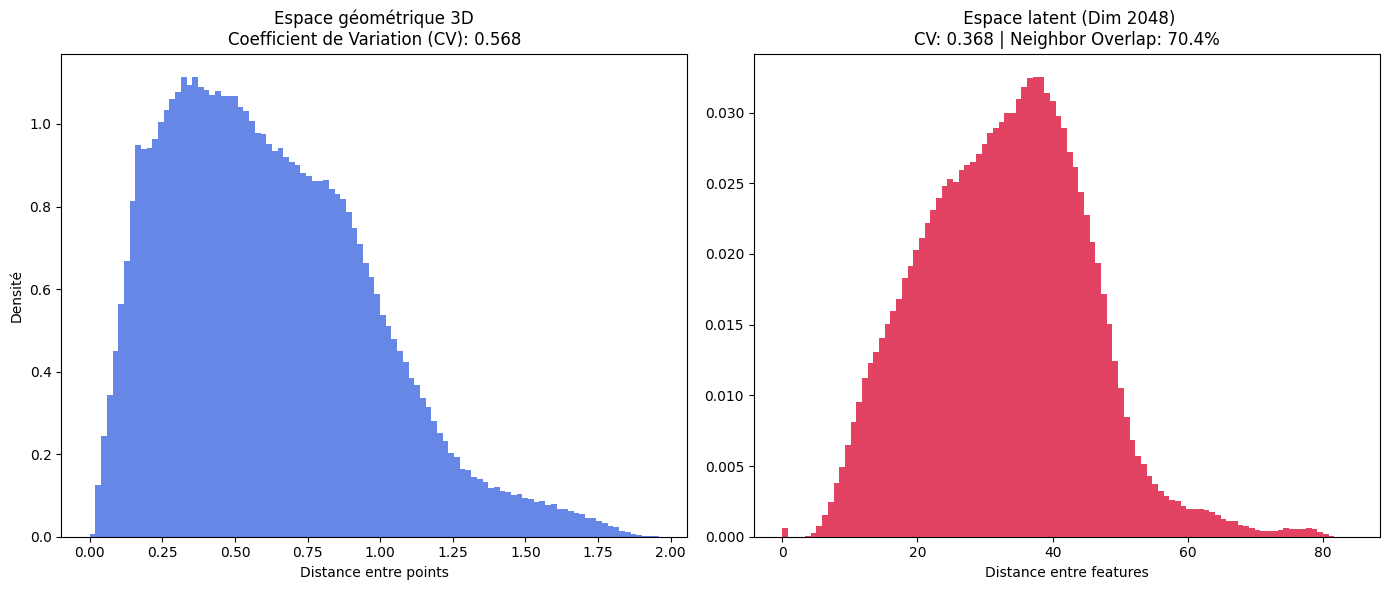

In [29]:
# Analyze distributions of distances
dist_in, dist_out, cv_in, cv_out, overlap = analyze_dimensionality_curse(
    model=trained_model, 
    test_loader=test_loader, 
    device=device, 
    k=20
)

plot_curse_of_dimensionality(dist_in, dist_out, cv_in, cv_out, overlap, extreme_dims[-1])

#### Distance distribution on untrained model

Using device: cuda
Random objects selected : Index 94, class [4]


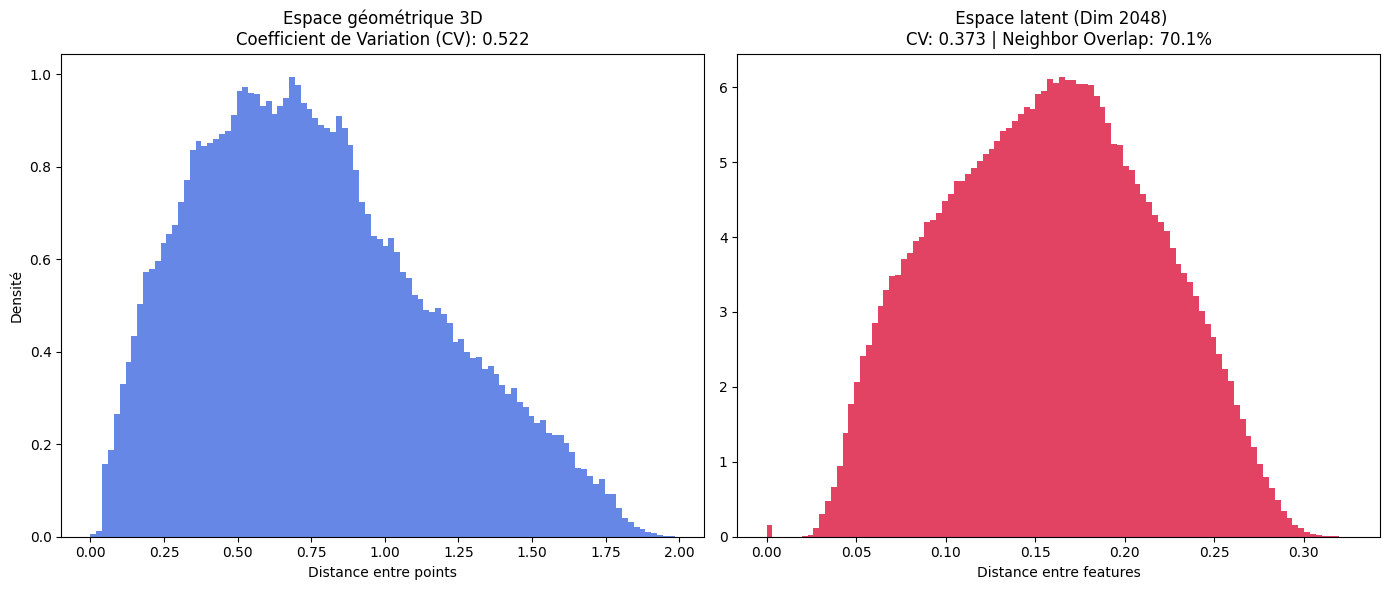

In [28]:
extreme_dims = [64, 128, 512, 2048]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

untrained_model = DGCNN(k=20, feature_dims=extreme_dims, output_channels=5).to(device)

dist_in, dist_out, cv_in, cv_out, overlap = analyze_dimensionality_curse(
    model=untrained_model, 
    test_loader=test_loader, 
    device=device, 
    k=20
)

plot_curse_of_dimensionality(dist_in, dist_out, cv_in, cv_out, overlap, extreme_dims[-1])

#### Comparisons of untrained and trained model 

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
import random 

def extract_feature_and_metrics(model, data_batch, k=20):
    """
    Extract features of the model and latent metrics
    """
    model.eval()
    device = next(model.parameters()).device
    x = data_batch.to(device)
    num_points = x.shape[2]
    
    with torch.no_grad():
        points_3d = x.squeeze(0).transpose(1, 0)
        dist_in = torch.cdist(points_3d, points_3d)
        dist_in_flat = dist_in.view(-1)[dist_in.view(-1) > 1e-5].cpu().numpy()
        idx_in = dist_in.topk(k=k+1, dim=-1, largest=False)[1][:, 1:]
        
        _, layer_outputs = model(x, return_features=True)
        feat_final = layer_outputs[-1].squeeze(0).transpose(1, 0) # (N, Dim)
        
        dist_out = torch.cdist(feat_final, feat_final)
        dist_out_flat = dist_out.view(-1)[dist_out.view(-1) > 1e-5].cpu().numpy()
        idx_out = dist_out.topk(k=k+1, dim=-1, largest=False)[1][:, 1:]
        
    cv_out = dist_out_flat.std() / dist_out_flat.mean()
    
    overlap_count = 0
    for i in range(num_points):
        overlap_count += len(set(idx_in[i].cpu().numpy()).intersection(set(idx_out[i].cpu().numpy())))
    overlap = (overlap_count / (num_points * k)) * 100
    
    return dist_out_flat, cv_out, overlap, feat_final.cpu().numpy(), points_3d.cpu().numpy()



c:\Users\octav\miniconda3\envs\NPM3D\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



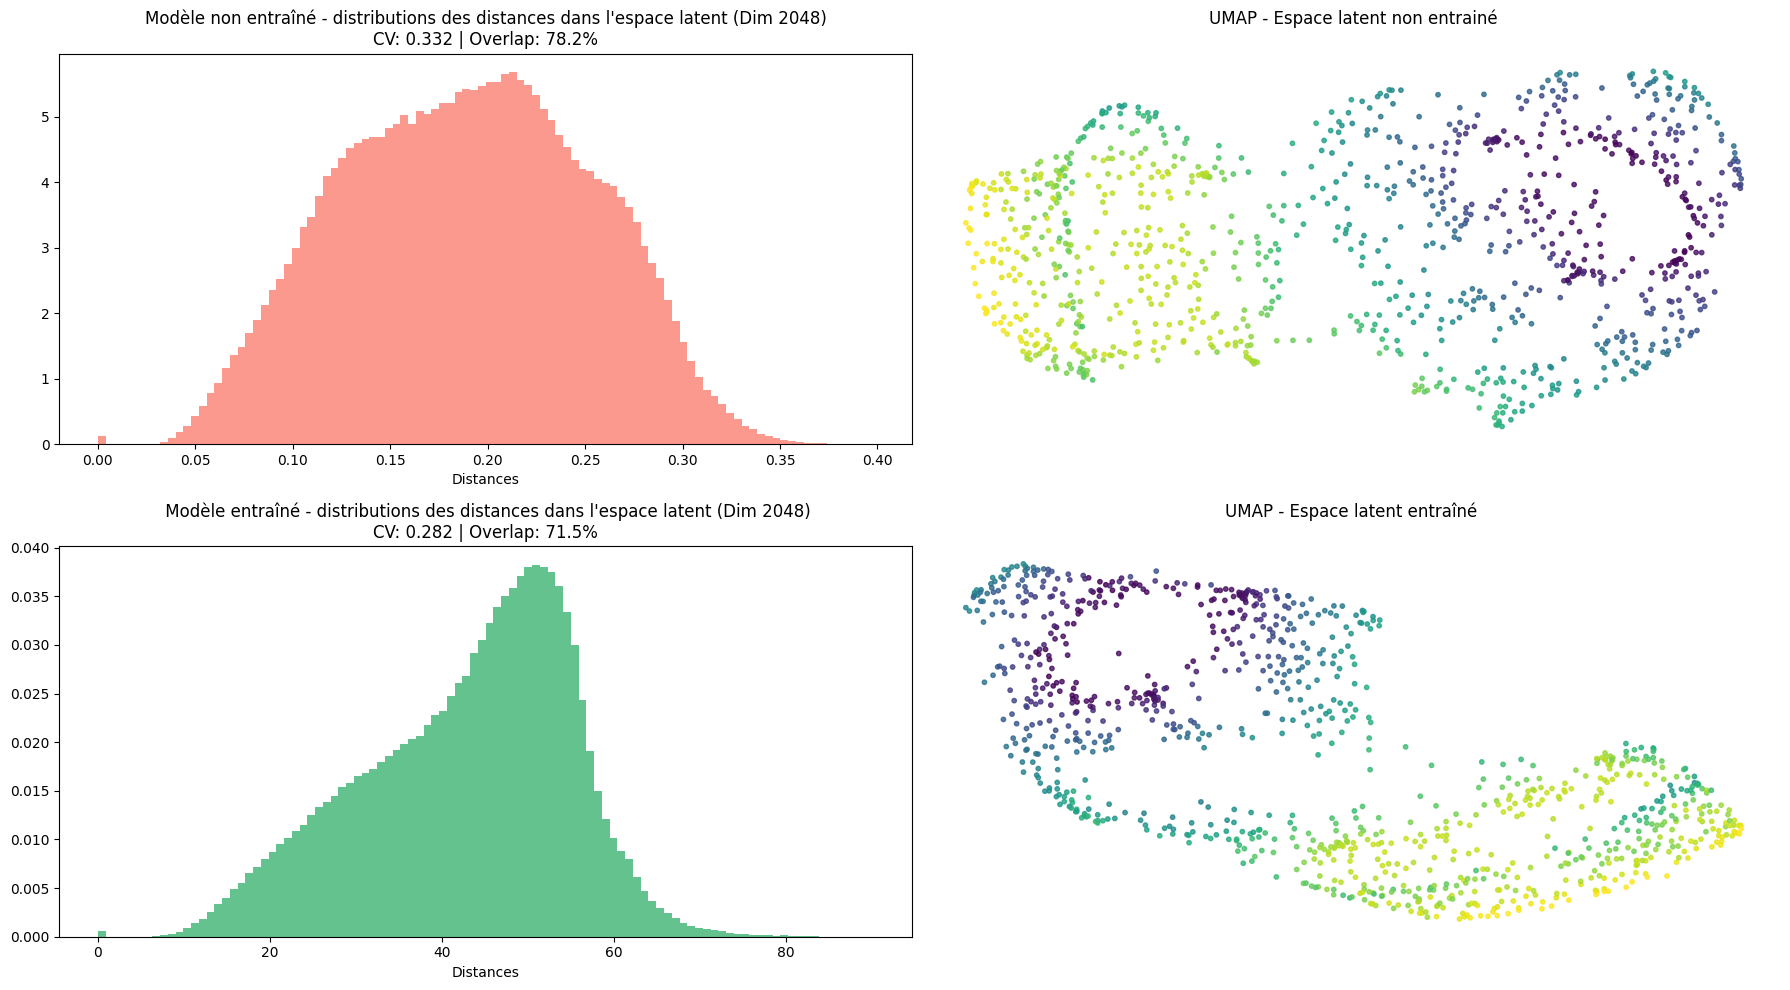

In [54]:
# Get random point cloud
dataset = test_loader.dataset
random_idx = random.randint(0, len(dataset) - 1)
data_point, label = dataset[random_idx] 

if not isinstance(data_point, torch.Tensor):
    data_point = torch.tensor(data_point)
if data_point.shape[0] != 3 and data_point.shape[1] == 3:
    data_point = data_point.transpose(1, 0)

x_input = data_point.unsqueeze(0).to(device).float()

# Creating the untrained model and keep the previous trained one
extreme_dims = [64, 128, 512, 2048]
untrained_model = DGCNN(k=20, feature_dims=extreme_dims, output_channels=40).to(device)

dist_un, cv_un, over_un, feat_un, xyz = extract_feature_and_metrics(untrained_model, x_input)

dist_tr, cv_tr, over_tr, feat_tr, _ = extract_feature_and_metrics(trained_model, x_input)

# Compute UMAP 
reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, metric='euclidean', random_state=42)
umap_un = reducer.fit_transform(feat_un)
umap_tr = reducer.fit_transform(feat_tr)

# Plot the comparison
plt.figure(figsize=(18, 10))

# untrained model 
plt.subplot(2, 2, 1)
plt.hist(dist_un, bins=100, color='salmon', alpha=0.8, density=True)
plt.title(f"Modèle non entraîné - distributions des distances dans l'espace latent (Dim 2048)\nCV: {cv_un:.3f} | Overlap: {over_un:.1f}%")
plt.xlabel("Distances")

plt.subplot(2, 2, 2)
plt.scatter(umap_un[:, 0], umap_un[:, 1], c=xyz[:, 2], cmap='viridis', s=10, alpha=0.8)
plt.title("UMAP - Espace latent non entrainé\n")
plt.axis('off')

# Trained model
plt.subplot(2, 2, 3)
plt.hist(dist_tr, bins=100, color='mediumseagreen', alpha=0.8, density=True)
plt.title(f" Modèle entraîné - distributions des distances dans l'espace latent (Dim 2048)\nCV: {cv_tr:.3f} | Overlap: {over_tr:.1f}%")
plt.xlabel("Distances")

plt.subplot(2, 2, 4)
plt.scatter(umap_tr[:, 0], umap_tr[:, 1], c=xyz[:, 2], cmap='viridis', s=10, alpha=0.8)
plt.title("UMAP - Espace latent entraîné \n")
plt.axis('off')

# plt.suptitle(f"Latent space structure and distance distribution of a trained and untrained model", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Oversmoothing

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def analyze_oversmoothing(model, data_batch, k=20):
    """
    Analyze the evolution of the Dirichlet energy and the global distance layer per layer. 
    """
    model.eval()
    device = next(model.parameters()).device
    
    if isinstance(data_batch, (list, tuple)):
        x = data_batch[0][0:1].to(device)
    else:
        x = data_batch[0:1].to(device)

    if x.shape[1] != 3 and x.shape[2] == 3: 
        x = x.permute(0, 2, 1)
        
    dirichlet_energies = []
    global_distances = []
    layer_names = ["Input"]
    
    def compute_metrics(features):
        """
        Compute the Dirichlet metrics
        """
        feat = features.squeeze(0).transpose(1, 0)
        
        dist_matrix = torch.cdist(feat.unsqueeze(0), feat.unsqueeze(0)).squeeze(0) 
        global_dist = dist_matrix.mean().item()
        
        idx = dist_matrix.topk(k=k+1, dim=-1, largest=False)[1][:, 1:] 
        neighbors = feat[idx] # (N, k, C)
        feat_expanded = feat.unsqueeze(1).expand(-1, k, -1) # (N, k, C)

        dirichlet_energy = (torch.norm(neighbors - feat_expanded, dim=2)**2).mean().item()
        return global_dist, dirichlet_energy

    with torch.no_grad():
        g_dist, d_energy = compute_metrics(x)
        global_distances.append(g_dist)
        dirichlet_energies.append(d_energy)
        
        base_idx = None
        if getattr(model, 'dynamic_graph', True) is False:
            base_idx = model.knn_fn(x, k=model.k, **model.knn_kwargs)

        curr_x = x

        for i, layer in enumerate(model.layers):
   
            curr_x = get_graph_feature(
                curr_x, 
                k=model.k,
                idx=base_idx,                  
                knn_fn=model.knn_fn,            
                knn_kwargs=model.knn_kwargs,    
                keep_xi=model.keep_xi          
            )
            
            curr_x = layer(curr_x)
            
            if model.aggr == 'max':
                curr_x = curr_x.max(dim=-1, keepdim=False)[0]
            elif model.aggr == 'sum':
                curr_x = curr_x.sum(dim=-1, keepdim=False)
            elif model.aggr == 'mean':
                curr_x = curr_x.mean(dim=-1, keepdim=False)
            
            g_dist, d_energy = compute_metrics(curr_x)
            global_distances.append(g_dist)
            dirichlet_energies.append(d_energy)
            layer_names.append(f"L{i+1}")
            
    return layer_names, dirichlet_energies, global_distances

#### Oversmoothing of an untrained model

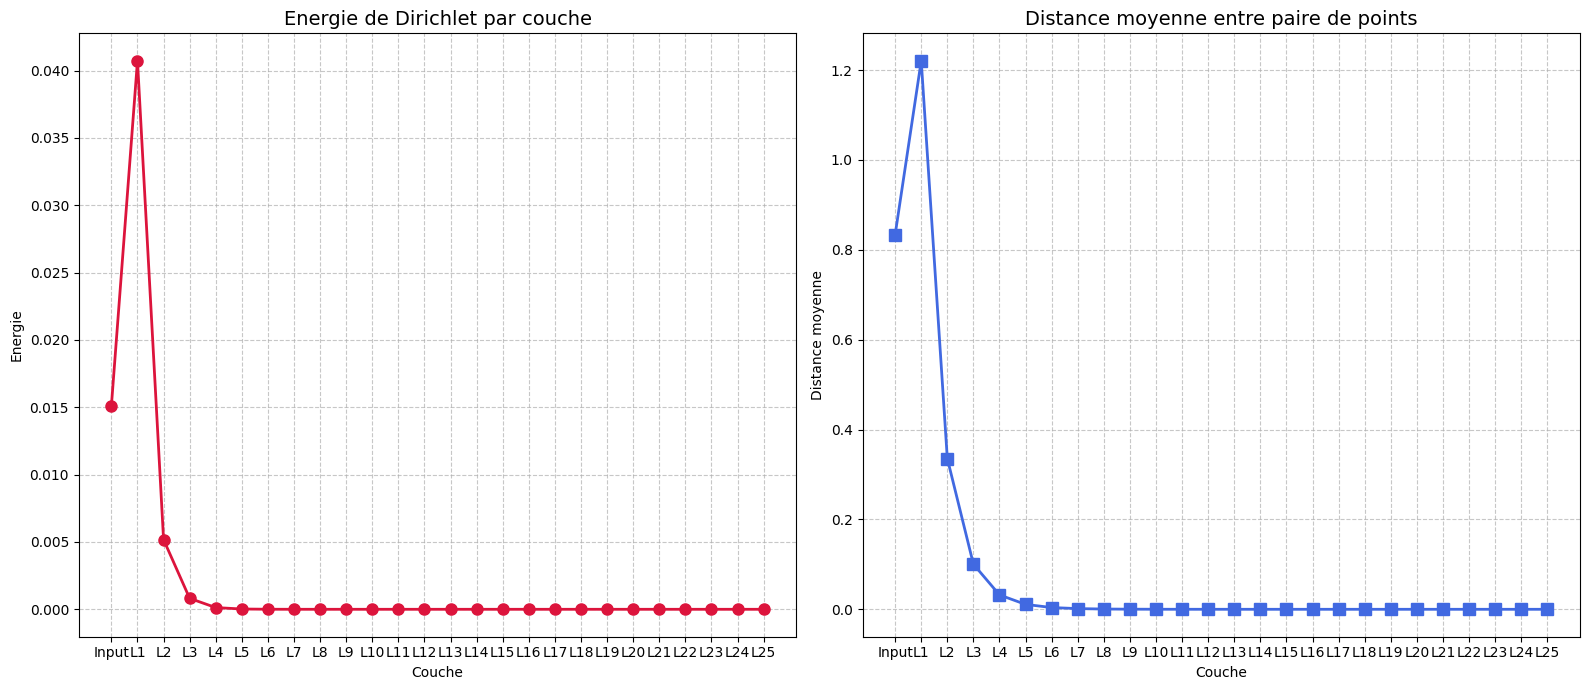

In [30]:

# Create a very large DGCNN
deep_dims = [64] * 25
deep_model = DGCNN(k=20, feature_dims=deep_dims, output_channels=10).to(device)
data, _ = next(iter(test_loader))
layers, energies, global_dists = analyze_oversmoothing(deep_model, data, k=20)

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(layers, energies, marker='o', color='crimson', linewidth=2, markersize=8)
plt.title("Energie de Dirichlet par couche",fontsize=14)
# plt.title("Dirichlet energy per layer", fontsize=14)
plt.ylabel("Energie")
plt.xlabel("Couche")
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(layers, global_dists, marker='s', color='royalblue', linewidth=2, markersize=8)
plt.title("Distance moyenne entre paire de points", fontsize=14)
plt.ylabel("Distance moyenne")
plt.xlabel("Couche")
plt.grid(True, linestyle='--', alpha=0.7)

# plt.suptitle("Evolution of dirichlet energy and mean distance over layers of an untrained model", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

#### Trained model with max

In [32]:
import torch
import matplotlib.pyplot as plt


deep_dims = [64] * 25
deep_model = DGCNN(k=20, feature_dims=deep_dims, output_channels=10).to(device)
data, _ = next(iter(test_loader))
layers_un, energies_un, dists_un = analyze_oversmoothing(deep_model, data, k=20)

config.epochs = 5
trained_deep_model = train_demo(deep_model, train_loader, test_loader, config, device)


Training on: CUDA...
Epoch 1/5 | Train Loss: 2.0910 | Train Acc: 0.3426
            Test Loss: 1.7872 | Test Acc: 0.4634
Epoch 2/5 | Train Loss: 1.6648 | Train Acc: 0.5743
            Test Loss: 1.3783 | Test Acc: 0.8122
Epoch 3/5 | Train Loss: 1.4920 | Train Acc: 0.7132
            Test Loss: 1.3331 | Test Acc: 0.7610
Epoch 4/5 | Train Loss: 1.3595 | Train Acc: 0.7838
            Test Loss: 1.1651 | Test Acc: 0.8951
Epoch 5/5 | Train Loss: 1.2899 | Train Acc: 0.8419
            Test Loss: 1.1038 | Test Acc: 0.9390
Training Finished, Best test precision : 0.9390


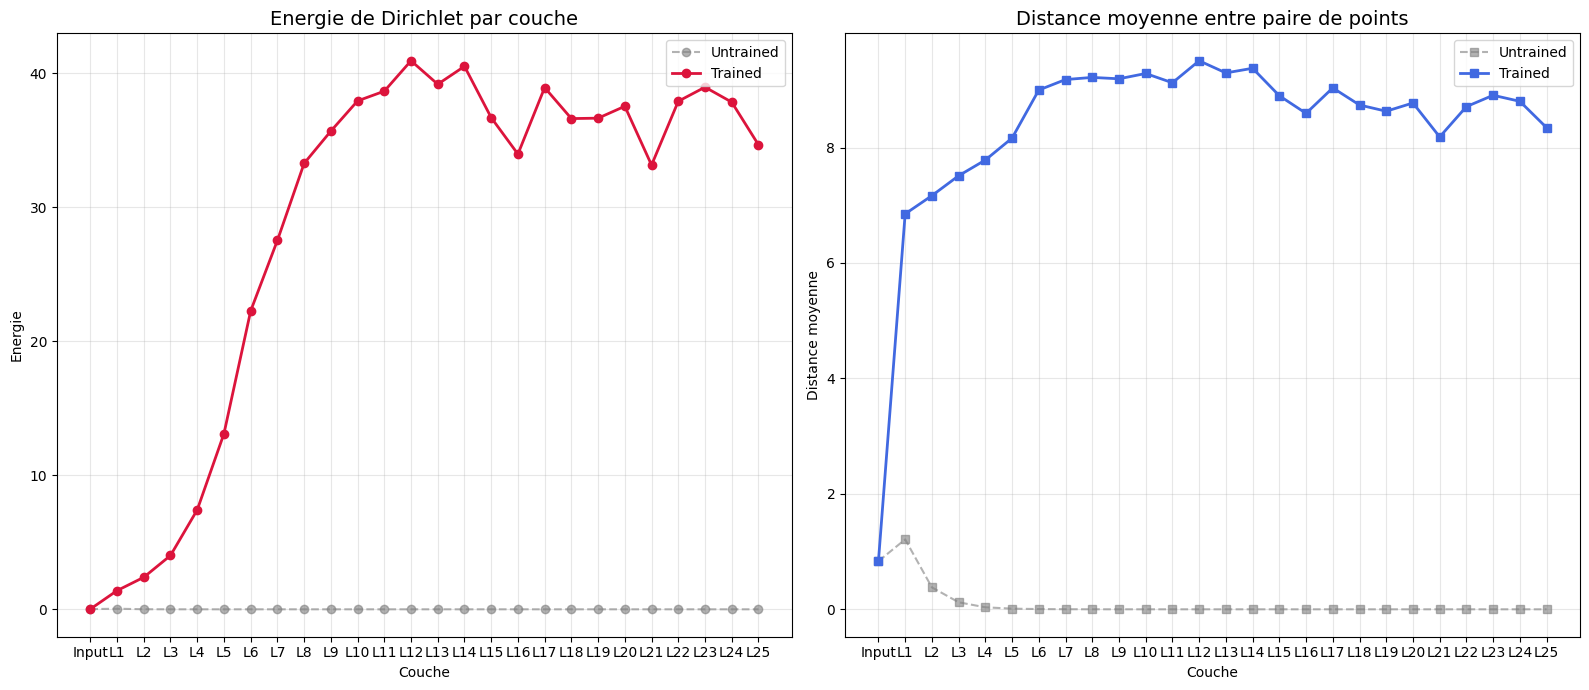

In [33]:

layers_tr, energies_tr, dists_tr = analyze_oversmoothing(trained_deep_model, data, k=20)

plt.figure(figsize=(16, 7))

# Plot 1: Dirichlet Energy (Local Smoothing)
plt.subplot(1, 2, 1)
plt.plot(layers_un, energies_un, 'o--', label='Untrained', color='gray', alpha=0.6)
plt.plot(layers_tr, energies_tr, 'o-', label='Trained', color='crimson', linewidth=2)
plt.title("Energie de Dirichlet par couche",fontsize=14)
plt.ylabel("Energie")
plt.xlabel("Couche")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Global Mean Distance (Global Contraction)
plt.subplot(1, 2, 2)
plt.plot(layers_un, dists_un, 's--', label='Untrained', color='gray', alpha=0.6)
plt.plot(layers_tr, dists_tr, 's-', label='Trained', color='royalblue', linewidth=2)
plt.title("Distance moyenne entre paire de points", fontsize=14)
plt.ylabel("Distance moyenne")
plt.xlabel("Couche")
plt.legend()
plt.grid(True, alpha=0.3)

# plt.suptitle("Evolution of dirichlet energy and mean distance over layers of a trained model", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Trained with mean and not dynamic

In [ ]:
import torch
import matplotlib.pyplot as plt


deep_dims = [64] * 25
deep_model = DGCNN(k=20, feature_dims=deep_dims, output_channels=10,aggr="mean",dynamic_graph=False).to(device)
data, _ = next(iter(test_loader))
layers_un, energies_un, dists_un = analyze_oversmoothing(deep_model, data, k=20)

config.epochs = 5
trained_deep_model = train_demo(deep_model, train_loader, test_loader, config, device)


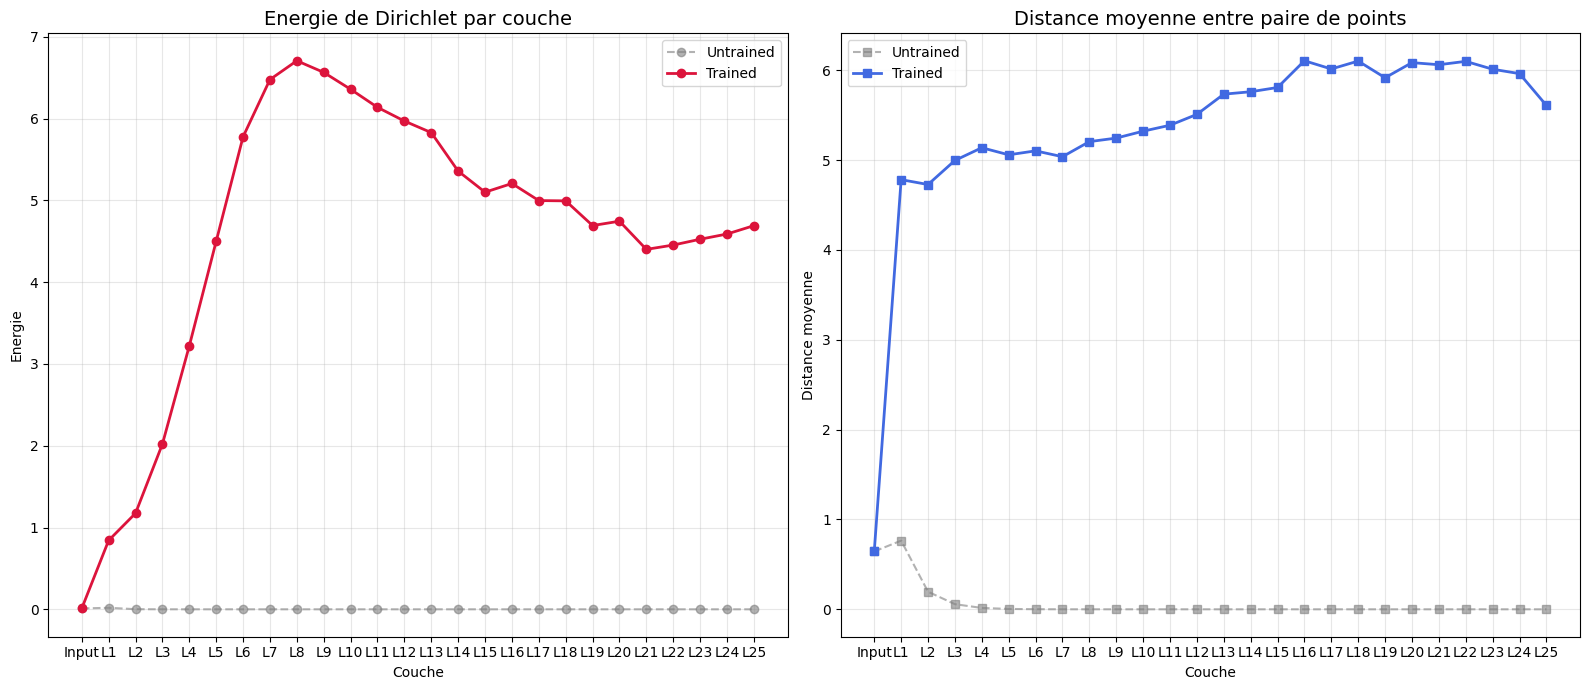

In [ ]:

layers_tr, energies_tr, dists_tr = analyze_oversmoothing(trained_deep_model, data, k=20)

plt.figure(figsize=(16, 7))

# Plot 1: Dirichlet Energy (Local Smoothing)
plt.subplot(1, 2, 1)
plt.plot(layers_un, energies_un, 'o--', label='Untrained', color='gray', alpha=0.6)
plt.plot(layers_tr, energies_tr, 'o-', label='Trained', color='crimson', linewidth=2)
plt.title("Energie de Dirichlet par couche",fontsize=14)
plt.ylabel("Energie")
plt.xlabel("Couche")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Global Mean Distance (Global Contraction)
plt.subplot(1, 2, 2)
plt.plot(layers_un, dists_un, 's--', label='Untrained', color='gray', alpha=0.6)
plt.plot(layers_tr, dists_tr, 's-', label='Trained', color='royalblue', linewidth=2)
plt.title("Distance moyenne entre paire de points", fontsize=14)
plt.ylabel("Distance moyenne")
plt.xlabel("Couche")
plt.legend()
plt.grid(True, alpha=0.3)

# plt.suptitle("Evolution of dirichlet energy and mean distance over layers of a trained model", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Training without xi

In [24]:
import torch
import matplotlib.pyplot as plt

deep_dims = [64] * 25
no_xi_deep_model = DGCNN(
    k=20, 
    feature_dims=deep_dims, 
    output_channels=10,
    aggr="max",          
    dynamic_graph=True,    
    keep_xi=False         
).to(device)

data, _ = next(iter(test_loader))
layers_un, energies_un, dists_un = analyze_oversmoothing(no_xi_deep_model, data, k=20)

config.epochs = 5
trained_no_xi_model = train_demo(no_xi_deep_model, train_loader, test_loader, config, device)



Training on: CUDA...
Epoch 1/5 | Train Loss: 2.1988 | Train Acc: 0.3509
            Test Loss: 3.0614 | Test Acc: 0.1818
Epoch 2/5 | Train Loss: 1.9730 | Train Acc: 0.4290
            Test Loss: 1.7969 | Test Acc: 0.4409
Epoch 3/5 | Train Loss: 1.9187 | Train Acc: 0.4574
            Test Loss: 1.7540 | Test Acc: 0.5500
Epoch 4/5 | Train Loss: 1.7830 | Train Acc: 0.5213
            Test Loss: 1.6783 | Test Acc: 0.5273
Epoch 5/5 | Train Loss: 1.7393 | Train Acc: 0.5497
            Test Loss: 1.5702 | Test Acc: 0.5500
Training Finished, Best test precision : 0.5500


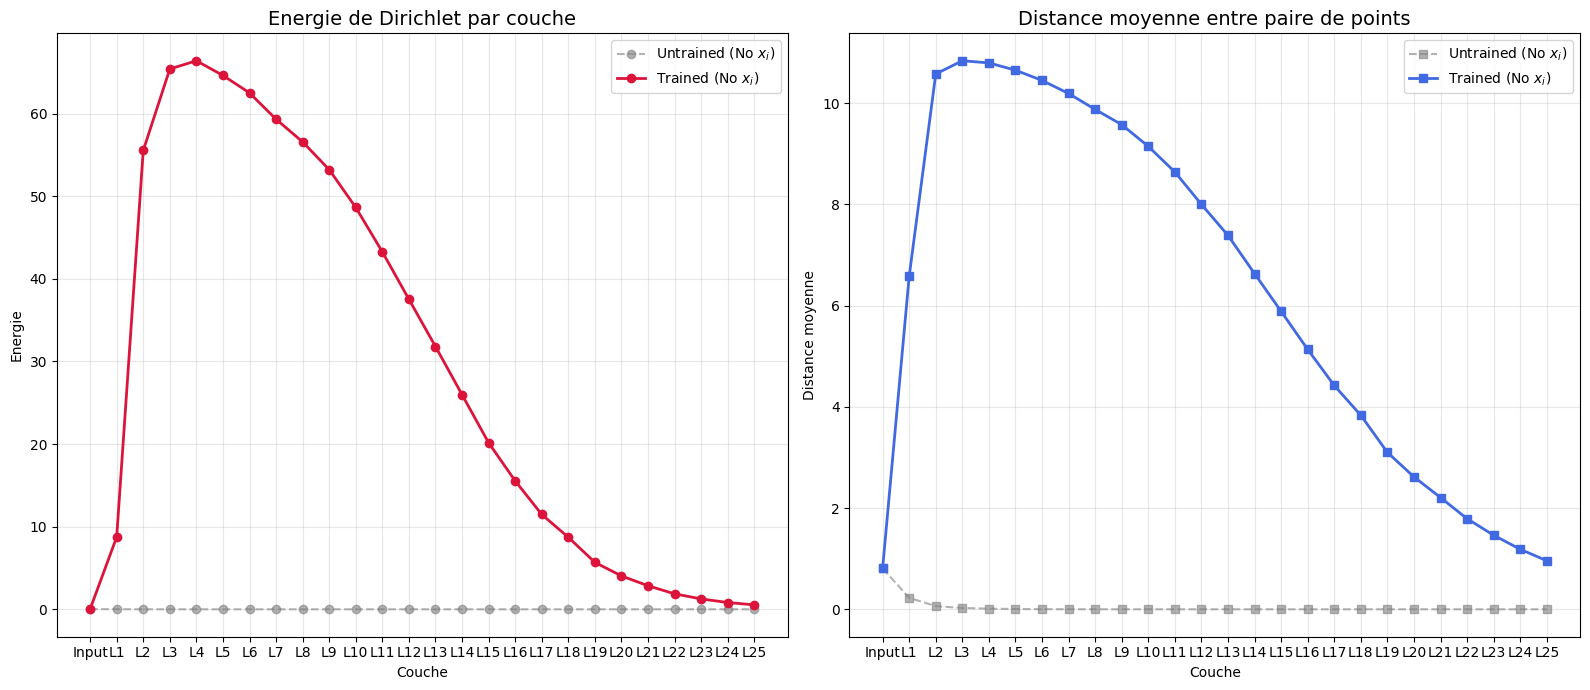

In [25]:

layers_tr, energies_tr, dists_tr = analyze_oversmoothing(trained_no_xi_model, data, k=20)

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(layers_un, energies_un, 'o--', label='Untrained (No $x_i$)', color='gray', alpha=0.6)
plt.plot(layers_tr, energies_tr, 'o-', label='Trained (No $x_i$)', color='crimson', linewidth=2)
plt.title("Energie de Dirichlet par couche",fontsize=14)
plt.ylabel("Energie")
plt.xlabel("Couche")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Global Mean Distance (Global Contraction
plt.subplot(1, 2, 2)
plt.plot(layers_un, dists_un, 's--', label='Untrained (No $x_i$)', color='gray', alpha=0.6)
plt.plot(layers_tr, dists_tr, 's-', label='Trained (No $x_i$)', color='royalblue', linewidth=2)
plt.title("Distance moyenne entre paire de points", fontsize=14)
plt.ylabel("Distance moyenne")
plt.xlabel("Couche")
plt.legend()
plt.grid(True, alpha=0.3)

# plt.suptitle("Evolution of dirichlet energy and mean distance over layers of a trained model by removing $x_i$", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Execution Time

In [ ]:
def benchmark_knn(N_list=None, k=20, C=3, B=2, n_runs=5, device="cuda"):
    """
    Comparison of execution time and memory usage of different KNN
    """
    import time

    if N_list is None:
        N_list = [512, 1024, 2048, 4096]

    variants = {
        "brute_force": (knn_brute_force, {}),
        "ball_query":  (knn_ball_query,  {"radius": 0.5}),
    }
    try:
        import pykeops 
        variants["keops"] = (knn_keops, {})
    except ImportError:
        print("[benchmark] KeOps not available")
    try:
        import faiss  
        variants["faiss"] = (knn_faiss, {})
    except ImportError:
        print("[benchmark] FAISS not available")

    print(f"\n{'─'*65}")
    print(f"{'Method':<15} {'N':>6} {'Time (ms)':>12} {'Memory usage (MB)':>14}")
    print(f"{'─'*65}")

    results = {}

    for N in N_list:
        x = torch.randn(B, C, N, device=device)
        for name, (fn, kwargs) in variants.items():
            times = []
            mems  = []
            for _ in range(n_runs):
                if device == "cuda":
                    torch.cuda.synchronize()
                    torch.cuda.reset_peak_memory_stats()
                t0 = time.perf_counter()
                _ = fn(x, k=k, **kwargs)
                if device == "cuda":
                    torch.cuda.synchronize()
                elapsed = (time.perf_counter() - t0) * 1000   # ms
                times.append(elapsed)
                if device == "cuda":
                    mems.append(torch.cuda.max_memory_allocated() / 1e6)  # MB

            avg_t = sum(times) / n_runs
            avg_m = sum(mems) / n_runs if mems else float("nan")
            results[(name, N)] = {"time_ms": avg_t, "mem_mb": avg_m}
            print(f"{name:<15} {N:>6} {avg_t:>12.2f} {avg_m:>14.1f}")

    print(f"{'─'*65}\n")
    return results


In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}\n")

for mode in ["brute_force", "ball_query"]:
    model = DGCNN(
        k=20,
        output_channels=40,
        knn_mode=mode,
        knn_kwargs={"radius": 0.3} if mode == "ball_query" else {},
    ).to(device)

    x = torch.randn(2, 3, 1024, device=device)
    out, _ = model(x)
    print(f"[{mode:>12}] output shape : {out.shape}")

# 2. Lancer le benchmark KNN
print("\n=== Benchmark KNN ===")
benchmark_knn(
    N_list=[512, 1024, 2048, 4096, 16384,32768],
    k=20,
    device=device,
)

**Configuration :**
> Device : `cuda`
> [brute_force] output shape : `torch.Size([2, 40])`
> [ball_query] output shape : `torch.Size([2, 40])`

| Method | N | Time (ms) | Memory usage (MB) |
| :--- | :---: | :---: | :---: |
| brute_force | 512 | 2.78 | 310.7 |
| ball_query | 512 | 2.93 | 310.9 |
| keops | 512 | 5.85 | 308.7 |
| brute_force | 1024 | 2.51 | 320.4 |
| ball_query | 1024 | 3.67 | 320.4 |
| keops | 1024 | 7.99 | 309.2 |
| brute_force | 2048 | 6.32 | 349.3 |
| ball_query | 2048 | 6.82 | 350.4 |
| keops | 2048 | 11.67 | 310.1 |
| brute_force | 4096 | 13.41 | 458.2 |
| ball_query | 4096 | 16.40 | 476.3 |
| keops | 4096 | 8.08 | 312.7 |
| brute_force | 16384 | 117.57 | 2515.4 |
| ball_query | 16384 | 148.36 | 2993.6 |
| keops | 16384 | 14.58 | 323.3 |
| brute_force | 32768 | 436.13 | 9051.6 |
| ball_query | 32768 | 568.93 | 11047.5 |
| keops | 32768 | 22.37 | 337.3 |